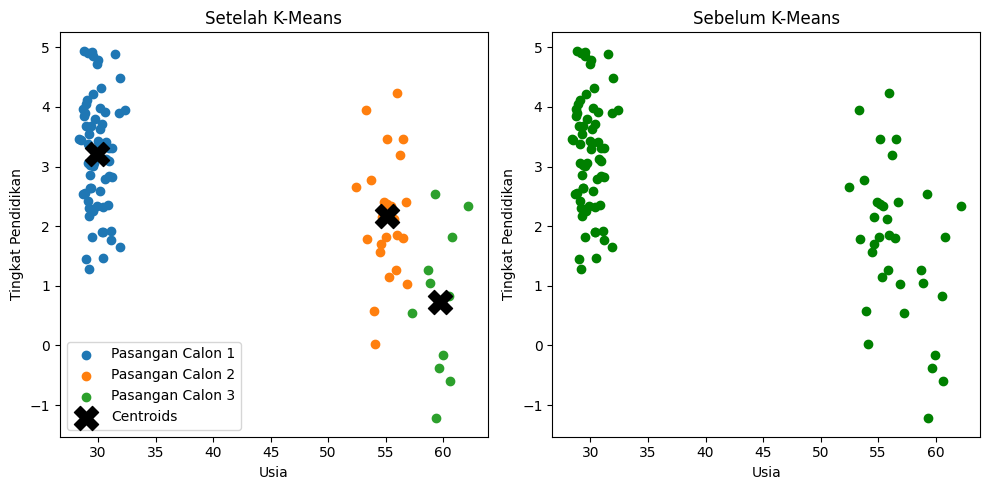

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Membuat data dummy untuk pemilih berdasarkan pasangan calon presiden
np.random.seed(0)

# Menggunakan fitur: Usia (18-65), Tingkat Pendidikan (1: Rendah, 2: Menengah, 3: Tinggi)
# Grup 1: Pasangan Calon No. 1 (Generasi Tua, Pendidikan Menengah, Miskin, Agama)
group1 = np.random.randn(25, 2) + [55, 2]  # 25 pemilih, umur sekitar 55 tahun, Pendidikan Menengah
# Grup 2: Pasangan Calon No. 2 (Generasi Muda, Pendidikan Tinggi, Pengusaha, Masyarakat Miskin dan Kaya)
group2 = np.random.randn(65, 2) + [30, 3]  # 65 pemilih, umur sekitar 30 tahun, Pendidikan Tinggi
# Grup 3: Pasangan Calon No. 3 (Generasi Tua, Pendidikan Rendah)
group3 = np.random.randn(10, 2) + [60, 1]  # 10 pemilih, umur sekitar 60 tahun, Pendidikan Rendah

# Menggabungkan data
data_final = np.vstack([group1, group2, group3])

# Menerapkan K-Means dengan 3 cluster
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(data_final)

# Mendapatkan pusat cluster (centroids)
centroids = kmeans.cluster_centers_

# Plot After K-Means
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
for i in range(3):
    plt.scatter(data_final[clusters == i, 0], data_final[clusters == i, 1], label=f'Pasangan Calon {i+1}')
    
# Menampilkan pusat cluster
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title("Setelah K-Means")
plt.xlabel("Usia")
plt.ylabel("Tingkat Pendidikan")
plt.legend()

# Plot Before K-Means (untuk perbandingan)
plt.subplot(1, 2, 2)
plt.scatter(data_final[:, 0], data_final[:, 1], color='green')
plt.title("Sebelum K-Means")
plt.xlabel("Usia")
plt.ylabel("Tingkat Pendidikan")

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

# 1. Mengumpulkan Data
data = {
    'hari': ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu'] * 10,
    'cuaca': ['Cerah', 'Hujan', 'Mendung', 'Cerah', 'Hujan', 'Mendung', 'Cerah'] * 10,
    'hari_libur': [0, 0, 0, 0, 1, 1, 0] * 10,
    'jumlah_roti_terjual': [100, 150, 200, 250, 300, 350, 400] * 10
}

# Membuat DataFrame
df = pd.DataFrame(data)

# 2. Pra-proses Data
label_encoder_hari = LabelEncoder()
label_encoder_cuaca = LabelEncoder()
df['hari'] = label_encoder_hari.fit_transform(df['hari'])
df['cuaca'] = label_encoder_cuaca.fit_transform(df['cuaca'])

# 3. Memisahkan Fitur dan Target
X = df.drop('jumlah_roti_terjual', axis=1)  # Fitur
y = df['jumlah_roti_terjual']  # Target

# 4. Membagi Data Menjadi Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Melatih Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Membuat Prediksi
y_pred = model.predict(X_test)

# 7. Evaluasi Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

# 8. Menggunakan Model untuk Prediksi Baru
data_baru = pd.DataFrame({
    'hari': label_encoder_hari.transform(['Senin']),  # Misal ingin memprediksi untuk hari Senin
    'cuaca': label_encoder_cuaca.transform(['Cerah']),  # Misal cuaca cerah
    'hari_libur': [0]  # Bukan hari libur
})

prediksi_jumlah_roti = model.predict(data_baru)
print("Prediksi jumlah roti terjual:", prediksi_jumlah_roti[0])

# 9. Visualisasi Hasil
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Garis referensi
plt.title('Perbandingan Jumlah Roti Terjual (Aktual vs Prediksi)')
plt.xlabel('Jumlah Roti Terjual (Aktual)')
plt.ylabel('Jumlah Roti Terjual (Prediksi)')
plt.xlim([0, 450])
plt.ylim([0, 450])
plt.grid()
plt.show()


Root Mean Squared Error (RMSE): 0.0
Prediksi jumlah roti terjual: 100.0
